Generate a random number with probabilities [0.1,0.9]

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt


1. What are we trying to estimate?

Suppose we have a random experiment with two possible outcomes:

$$ A \quad\text{or}\quad B $$

In the code,


```
myRV = random.choices('AB', weights=[1,9], k=k)
```

means that each experiment has

$$ P(A)=0.1,\qquad P(B)=0.9. $$

We know these probabilities because we specified them in the code. But imagine that we did not know \(P(B)\). We could perform the experiment many times and try to estimate it.

For example, if we perform the experiment 100 times and observe B 87 times, a natural estimate is

$$ \hat p = \frac{87}{100}=0.87. $$


The symbol $\hat{p}$ , read "p-hat", means our estimate of $p$.

[1.]
[1.  0.9]
[1.    0.9   0.882]
[1.     0.9    0.882  0.9041]


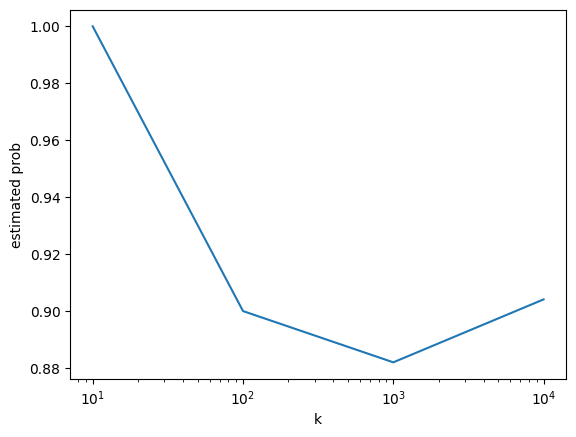

In [51]:
# We repeat a random experiment k times.
# Each experiment gives either A or B, with P(B) = 0.9.
# The fraction of B's is our estimate of P(B).


p_hat=np.array([])
for logk in np.arange(1,5):
  k=10**logk
  myRV= random.choices('AB', weights= [1,9], k=k)
  p_hat= np.append(p_hat, myRV.count('B')/k)
  print(p_hat)


fig,ax=plt.subplots()
ax.plot(10**np.arange(1,5),p_hat)
ax.set_xscale('log')
ax.set_xlabel('k')
ax.set_ylabel('estimated prob')
plt.show()


Run the code above multiple times.

Everytime we run this we get a different estimate, the estimate itself is a random variable. So we can see how this random variable is distributed.

/tmp/ipykernel_1903/3022769547.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot(c, labels= 10**np.arange(1,Nk+1))


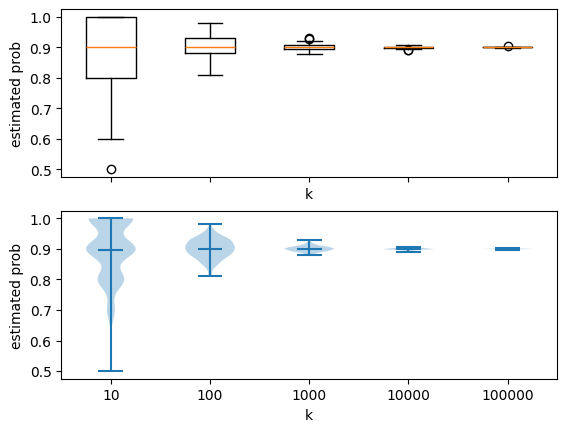

In [39]:
# One run gives only one estimate.
# To see how variable the estimate is, we repeat the whole
# estimation procedure many times.

Nk= 5 # k variaes from k^1 to K^Nk
nTries= 300 # we run the experiment nTries times
c=np.empty(shape=(nTries,Nk))
for t in np.arange(0,nTries):
  for logk in np.arange(0,Nk):
    k=10**(logk+1)
    myRV= random.choices('AB', weights= [1,9], k=k)
    c[t, logk]= myRV.count('B')/k

Each column contains 300 estimates obtained from independent runs.
The plots show how the distribution of the estimate changes with k.
We expect the distribution to become narrower as k increases.

In [ ]:
fig,ax=plt.subplots(nrows=2, ncols=1, sharex=True)
ax[0].boxplot(c, labels= 10**np.arange(1,Nk+1))
ax[0].set_xlabel('k')
ax[0].set_ylabel('estimated prob')

ax[1].violinplot(c, showmeans=True)
ax[1].set_xlabel('k')
ax[1].set_ylabel('estimated prob')
plt.show()

We now measure the spread of the estimates using their standard deviation.

Theory predicts that this spread decreases proportionally $\frac{1}{\sqrt(N)}$

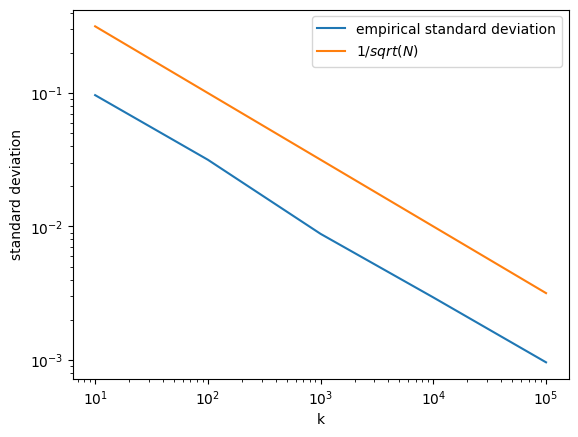

In [50]:
fig,ax=plt.subplots()
ax.plot(10**np.arange(1,Nk+1), c.std(axis=0), label='empirical standard deviation')
ax.plot(10**np.arange(1,Nk+1), 1/np.sqrt(10**np.arange(1,Nk+1)), label='$1/sqrt(N)$')

ax.set_xlabel('k')
ax.set_ylabel('standard deviation')
ax.set_xscale('log')
# ax.set_yscale('log')
ax.legend()

Why the trend looks ok, but there is a shift?


For a Bernoulli probability p, the theoretical standard deviation of the estimated probability is

$$\sqrt{\frac{{p} . (1-{p})}{N}} $$

In this example p = 0.9, so this is

$$0.3 / \sqrt(N)$$

We first compare the simulation with $1/\sqrt(N)$ to check the scaling.
The vertical shift is explained by the factor $\sqrt(p*(1-p))$.





# Summary

We started with a random experiment with two possible outcomes: A and B.

In our example,

    P(A) = 0.1
    P(B) = 0.9

We can represent the outcome as a Bernoulli random variable:

    X = 1 if we observe B
    X = 0 if we observe A

If we repeat the experiment N times, the fraction of B's is

    p_hat = number of B's / N

This is our estimate of the unknown probability p.

The important point is that p_hat is itself random.
If we repeat the whole experiment, we get a different sample
and therefore a different estimate.

This is why we repeated the estimation procedure many times.
The boxplots and violin plots show the distribution of these
different estimates.

As N increases, the estimates become more concentrated around
the true probability p. In other words, the estimate becomes
more precise.

We measured this precision using the standard deviation of the
estimates.

For a Bernoulli random variable, the theoretical standard
deviation of the estimated probability is

                 sqrt(p(1-p))
    SD(p_hat) = ---------------
                    sqrt(N)

Therefore,

    SD(p_hat) is proportional to 1 / sqrt(N).

This means that increasing the number of observations reduces
the uncertainty in our estimate.

In this example p = 0.9, so

    sqrt(p(1-p)) = sqrt(0.9 * 0.1) = 0.3

and therefore

    SD(p_hat) = 0.3 / sqrt(N).

This explains why the empirical standard deviation has the same
general shape as 1/sqrt(N), but is shifted vertically.

In practice, we usually do not know p. We only have our estimate
p_hat. Therefore we can estimate the standard deviation using

                 sqrt(p_hat(1-p_hat))
    estimated SD = -------------------
                         sqrt(N)

This is called the standard error of the estimated probability.


# Challenge

Now investigate the behavior of the estimate yourself.

1. Change the number of samples N.

   Try, for example,

       N = 5
       N = 10
       N = 20
       N = 30
       N = 100
       N = 1000

   For each value of N, repeat the estimation many times.

2. Choose one value of N and plot a histogram of the estimates.

   For example, collect 1000 estimates for N = 20 and plot:

       plt.hist(estimates)

3. Repeat the histogram for several different values of N.

4. Compare what you see for small N and large N.

   In particular, investigate:

       N < 30

   versus

       N > 30

   What changes in the shape of the distribution?

5. Finally, try changing the probability itself.

   Instead of

       P(B) = 0.9

   try values such as

       P(B) = 0.5
       P(B) = 0.1

   Does the distribution of the estimates look the same?

Try to explain what you see and why you think it happens.